<a href="https://colab.research.google.com/github/Jude-Ufoh/Pytorch/blob/main/Linear%20Regression/Pytorch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [165]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [166]:
import torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(torch.__version__)


2.10.0+cpu


In [167]:
x = torch.tensor([[1, 2], [3,4],[6,5]])
print(x.ndim)
x[0]

2


tensor([1, 2])

### Random Tensors

In [168]:
x= torch.rand(3,2,2)
x

tensor([[[0.8694, 0.5677],
         [0.7411, 0.4294]],

        [[0.8854, 0.5739],
         [0.2666, 0.6274]],

        [[0.2696, 0.4414],
         [0.2969, 0.8317]]])

### zeros and ones

In [169]:
zeros = torch.zeros(3,4)
ones = torch.ones(3,4)
zeros, ones

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]))

### Creating a tensor range
A tensor range is created using functions like arange() (step-based) or linspace() (evenly spaced values)

In [170]:
# creating a range

y= torch.arange(2,5,1)
y

tensor([2, 3, 4])

### Getting information from tensors

In [171]:
z= torch.rand(1,3,4)
z

tensor([[[0.1053, 0.2695, 0.3588, 0.1994],
         [0.5472, 0.0062, 0.9516, 0.0753],
         [0.8860, 0.5832, 0.3376, 0.8090]]])

In [172]:
z.dtype
z.size()

torch.Size([1, 3, 4])

## Tensor Aggregation

In [173]:
x = torch.arange(0,100,5)
x.size()

torch.Size([20])

In [174]:
x.type(torch.float32).mean()

tensor(47.5000)

In [175]:
torch.mean(x.type(torch.float32))

tensor(47.5000)

In [176]:
y= torch.rand(3,6)
y

tensor([[0.5779, 0.9040, 0.5547, 0.3423, 0.6343, 0.3644],
        [0.7104, 0.9464, 0.7890, 0.2814, 0.7886, 0.5895],
        [0.7539, 0.1952, 0.0050, 0.3068, 0.1165, 0.9103]])

In [177]:
y.argmin()

tensor(14)

In [178]:
z=torch.arange(1,8)
z

tensor([1, 2, 3, 4, 5, 6, 7])

In [179]:
z1=z.reshape(1,7)
z1.shape


torch.Size([1, 7])

In [180]:
z_stacked = torch.stack([z,z,z,z], dim=1)
z_stacked

tensor([[1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3],
        [4, 4, 4, 4],
        [5, 5, 5, 5],
        [6, 6, 6, 6],
        [7, 7, 7, 7]])

In [181]:
a= torch.rand(1,2,1,4)
a

tensor([[[[0.6440, 0.7071, 0.6581, 0.4913]],

         [[0.8913, 0.1447, 0.5315, 0.1587]]]])

In [182]:
b = torch.arange(1, 10).reshape(1, 3, 3)
b, b.shape



(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [183]:
b[:,1,2]

tensor([6])

In [184]:
import numpy as np

a = np.random.rand(2, 3)
t = torch.from_numpy(a)

In [185]:
a[0, 0] = 999
print(t)

tensor([[9.9900e+02, 6.4693e-01, 7.9006e-02],
        [3.0333e-01, 6.6545e-01, 2.7232e-01]], dtype=torch.float64)


## Pytorch Workflow (Linear regression)

In [186]:
import torch
from torch import nn
import matplotlib.pyplot as plt
#checking the version of pytorch
torch.__version__

'2.10.0+cpu'

# Getting Data

In [187]:
# we will use a simple regression formula to create single features and single labels
# formula y =mX + C where m= Weight = 0.7 and C= bias= 0.3 and y =label, X = features
# using pytorch to create the values of X starting from 0, and ending at 1 with increament of 0.02 and corresponding values of y
X= torch.arange(0,1,0.02).unsqueeze(dim=1)

y= 0.7*X + 0.3

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [188]:
# Splitting the data into Training (80%) and testing sets (20%)
splitting_factor = int(0.8*len(X))

#Using the splitting factor to partition the the X and y data
X_train, y_train = X[:splitting_factor], y[:splitting_factor]
X_test, y_test = X[splitting_factor:], y[splitting_factor:]


In [189]:
# Creatin a function to visualise our data
def plot_data(train_features= X_train,
              train_labels=y_train,
              test_features=X_test,
              test_labels=y_test,
              predictions=None):
  """
  Plots training data, test data and compares predictions
  """
  plt.figure(figsize=(8,5))
  # Plot training data in  blue
  plt.scatter(train_features, train_labels, c="b", s=4, label="Training data")
  # Plot test data in green
  plt.scatter(test_features, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the prediction in red(if predictions were made on the test)
    plt.scatter(test_features, predictions, c="r", s=4, label="Predictions")
  # Show the legend
  plt.legend(prop={"size": 14})
  plt.show()

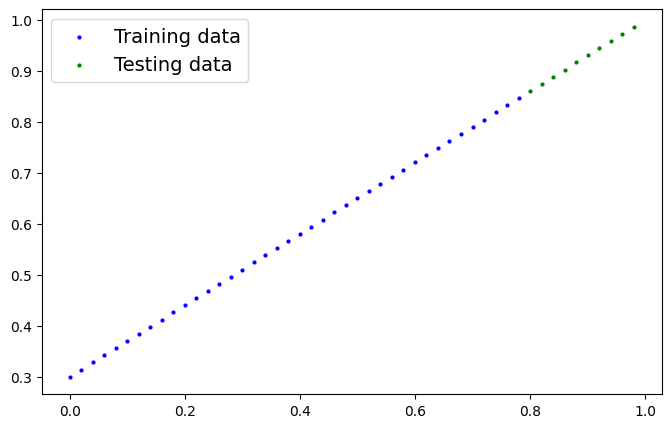

In [190]:
plot_data()

In [191]:
# Creating a Linear Regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights =nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) ->torch.Tensor:
    return self.weights * x + self.bias


In [192]:
# creating a manual seed
torch.manual_seed(42)

#creating an instance of the model
model_0 = LinearRegressionModel()

# checkout the parameters
list(model_0.parameters())

#checking the state of the model
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [193]:
# Using torch.inference_mode() to make prediction (this is only used when the model is being used to make a prediction)
with torch.inference_mode():
  y_preds = model_0(X_test)

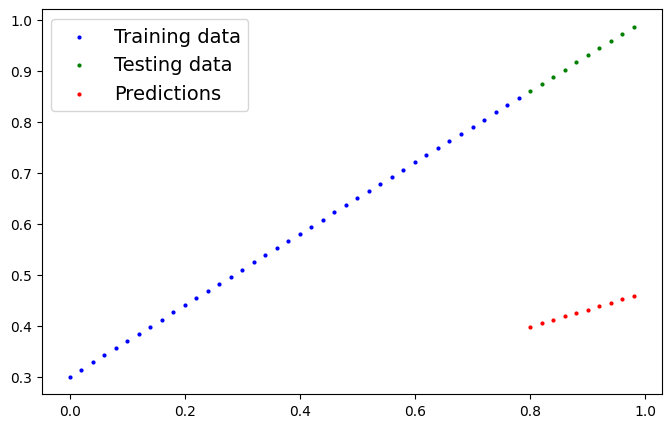

In [194]:
# We now have prediction. Let's checkout what the plot looks like
plot_data(predictions=y_preds)

In [195]:
#Checking y_test-y_pred
y_test-y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [196]:
#### from the last graph and last result, it is clear that model is doing very bad.
#### this is is because it has not been trained.
#### to train it, we will need a loss function and optimiser

loss_fn = nn.L1Loss()

#Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


In [197]:
# Next we train the model for 100 epochs
epochs = 200

train_loss_values =[]
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  model_0.train()
  y_pred = model_0(X_train)
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #Testing
  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred,y_test.type(torch.float))

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819
Epoch: 100 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262
Epoch: 110 | MAE Train Loss: 0.021020207554101944 | MAE Test Loss:

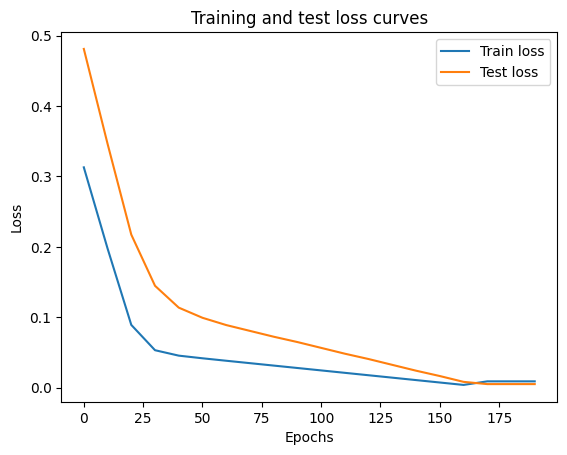

In [198]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

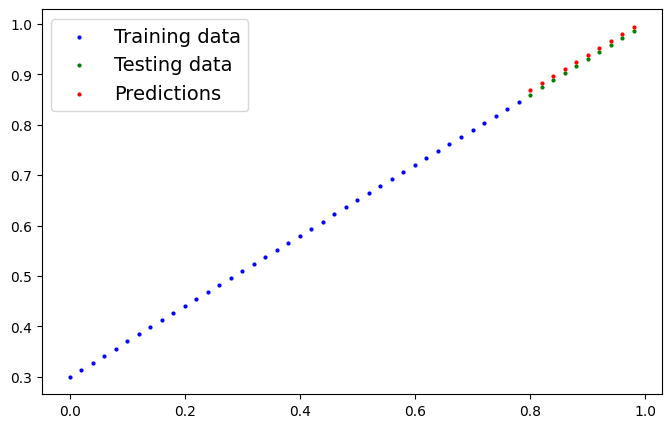

In [199]:

plot_data(predictions=test_pred)

In [200]:
print(model_0.state_dict())

OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})


## Saving the model

In [201]:
from pathlib import Path

# creating directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Creating a model save path
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# saving the model state dict
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow_model_0.pth


## Loading the Pytorch Model

In [202]:
# first we instatiate a new instance of the model
loaded_model_0 = LinearRegressionModel()

#Load the state_dict of our saved model (this will update the new instance of the model)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>